## Percorso migliore per il giro delle provincie

In [1]:
import numpy as np
import matplotlib.pyplot as plt 


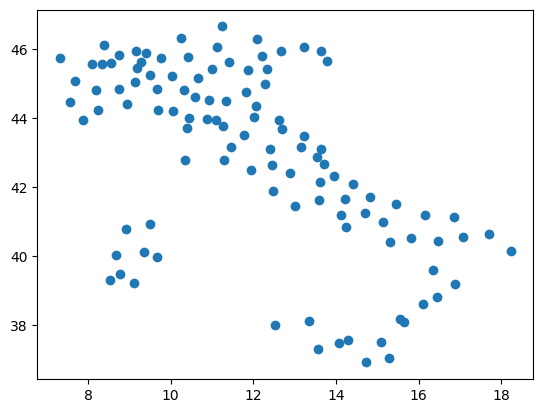

In [2]:
x,y = np.loadtxt("../INPUT/cap_prov_ita.dat", unpack= True)
plt.scatter(x, y)

# Risultato ottenuto senza parallelizzazione
Ottenuto usando una popolazione di 200 individui e 10000 epoche.

Lunghezza del percorso migliore = 69.84252010355698


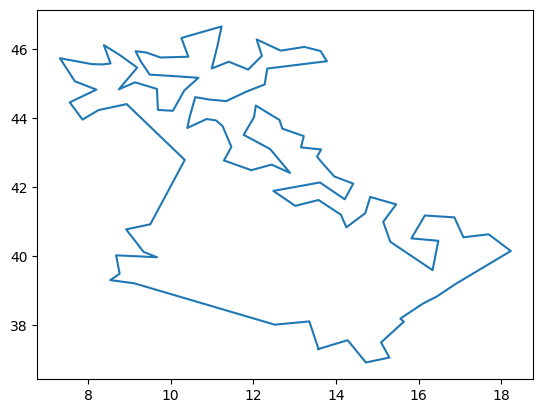

In [3]:
a = np.loadtxt("../OUTPUT/best_senza_parallelizzazione.dat", dtype= int)
x_f= x[a]
y_f = y[a]
plt.plot(x_f, y_f)

dx = np.diff(x_f) 
dy = np.diff(y_f)

l = np.sqrt(dx**2 + dy**2)
lunghezza= np.sum(l)
print (f"Lunghezza del percorso migliore = {lunghezza}")

Questo risultato è stato ottenuto con l'algoritmo dell'esercizio 9, non parallelizzato 

# Risultati ottenuto con parallelizzazione


100 individui, 3000 epoche, 10 core:

lunghezza percorso con migrazioni = 67.81905724015199
lunghezza percorso senza migrazioni = 80.03538313643594


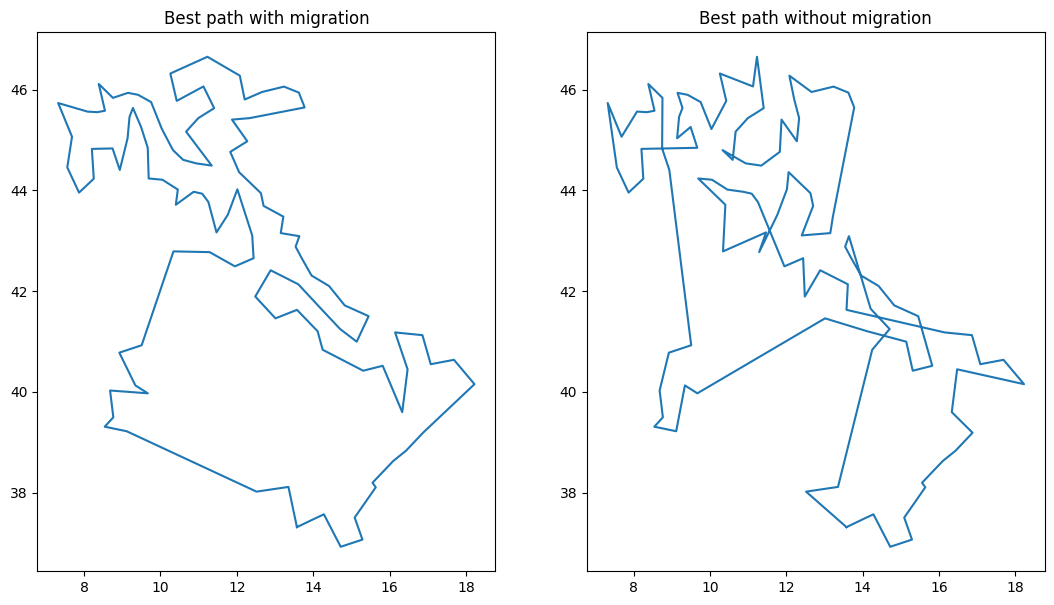

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7))

a2 = np.loadtxt("../OUTPUT/best_p_dip.dat", dtype= int)
a3= np.loadtxt("../OUTPUT/best_p_ind.dat", dtype= int)

x_2= x[a2]
y_2 = y[a2]

x_3= x[a3]
y_3 = y[a3]

ax1.plot(x_2, y_2)
ax1.set_title("Best path with migration")

ax2.plot(x_3, y_3)
ax2.set_title("Best path without migration")

dx = np.diff(x_2) 
dy = np.diff(y_2)

l1 = np.sqrt(np.diff(x_2)**2 + np.diff(y_2)**2)
l2 = np.sqrt(np.diff(x_3)**2 + np.diff(y_3)**2)

lun1= np.sum(l1)
lun2= np.sum(l2)
print (f"lunghezza percorso con migrazioni = {lun1}")
print (f"lunghezza percorso senza migrazioni = {lun2}")

Vediamo chiaramente che con isole indipendenti i risultati sono peggiori.

# Altri metodi
Ho provato metodi alternativi per l'algoritmo genetico:
1) Isole eterogenee: ci sono 3 tipi di isole che si differenziano per la probabilità di mutazione e per il modo in cui viene selezionata la nuova generazione. Le isole si passano casualmente gli individui migliori
2) Isole a "temperature" diverse: nell'isola 0 la probabilità di mutazione è la più bassa poi aumenta gradualmente aumentando il rank. gli individui migrano solo verso isole "più fredde".

100 individui, 3000 epoche, 14 core usando lo stesso algoritmo genetico usato in precedenza.
Migrazioni ogni 100 epoche, in alcune isole la probabilità di mutazione è più alta.

lunghezza percorso metodo 1 = 68.13735641347365
lunghezza percorso mmetodo 2 = 68.94264718102836


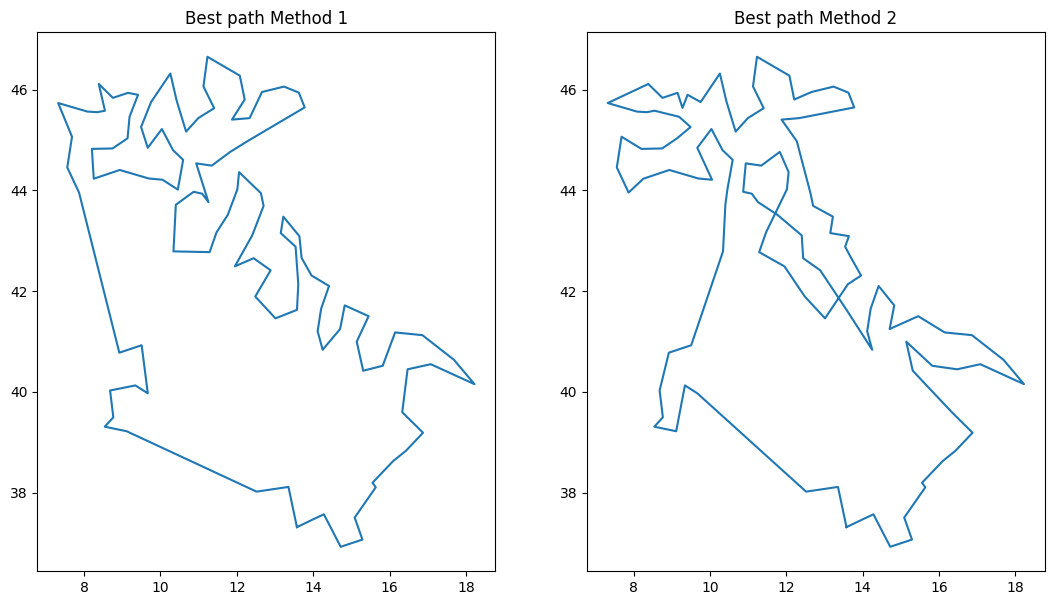

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7))

a2 = np.loadtxt("../OUTPUT/best_p_eterogenee1.dat", dtype= int)
a3= np.loadtxt("../OUTPUT/best_p_vars.dat", dtype= int)

x_2= x[a2]
y_2 = y[a2]

x_3= x[a3]
y_3 = y[a3]

ax1.plot(x_2, y_2)
ax1.set_title("Best path Method 1")

ax2.plot(x_3, y_3)
ax2.set_title("Best path Method 2")

dx = np.diff(x_2) 
dy = np.diff(y_2)

l1 = np.sqrt(np.diff(x_2)**2 + np.diff(y_2)**2)
l2 = np.sqrt(np.diff(x_3)**2 + np.diff(y_3)**2)

lun1= np.sum(l1)
lun2= np.sum(l2)
print (f"lunghezza percorso metodo 1 = {lun1}")
print (f"lunghezza percorso mmetodo 2 = {lun2}")

Vediamo che con 100 individui e 3000 epoche otteniamo risultati leggermente peggiori rispetto all'algoritmo classico. 


# Simulazioni più lunghe
Con simulazioni più lunghe abbiamo alcune sorprese:


200 individui, 5000 epoche, 15 core 
Il risultato migliore ottenuto è stato trovato con il metodo 2, quindi con le isole più calde e più fredde

lunghezza percorso metodo 2 = 65.64299345683435


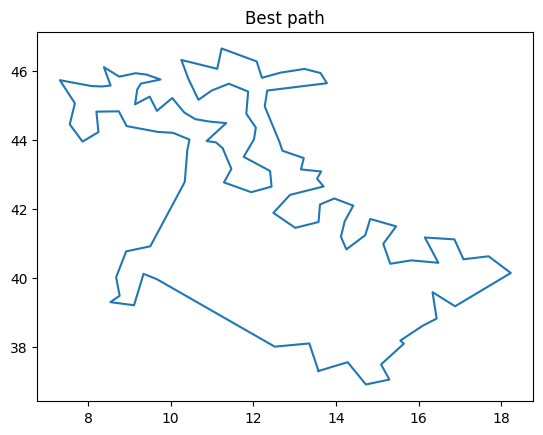

In [28]:
a2 = np.loadtxt("../OUTPUT/best_p_var4.dat", dtype= int)
x_2= x[a2]
y_2 = y[a2]

plt.plot(x_2, y_2)
plt.title("Best path")

dx = np.diff(x_2) 
dy = np.diff(y_2)

l = np.sqrt(dx**2 + dy**2)
lunghezza= np.sum(l)
print(f"lunghezza percorso metodo 2 = {lunghezza}")

Questo risultato però non è sufficiente a dimostrare che un metodo sia migliore dell'altro. Infatti il principale problema che ho riscontrato è la quantità di "gradi di libertà" che contraddistinguono questi algoritmi.

Probabilmente i paramentri che ho scelto non sono i migliori ma è anche difficile cercare di indagare i parametri migliori a causa del tempo richiesto per questi algoritmi e per il gran numero di parametri.

In più algoritmi che sembrano meno efficaci su simulazioni brevi non è detto che lo siano su tempi lunghi e questo complica notevolmente sia la scelta dell'algoritmo che la scelta dei parametri.